In [1]:
pip install jieba

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd     # 数据表
import numpy as np     # 数组
import re     # 正则表达式
import jieba     # 中文分词
import matplotlib.pyplot as plt     # 画图
from gensim.models import Word2Vec     # 训练词嵌入模型
# import gensim.downloader as api     # 导入云端的已训练好的词向量
from gensim.models import KeyedVectors     # 加载自己本地个性化的已训练好的词向量
from sklearn.metrics.pairwise import cosine_similarity     # 计算向量之间的余弦相似度
from sklearn.decomposition import PCA     # 语义空间降维，用于展示词语在二维空间的相对位置

In [3]:
df = pd.read_excel('小红书.xlsx', index_col = 0)
df[:20]

,avatar-item src,name,name href,note-text,date,count,count 2,note-content-emoji src 5
avatar href,,,,,,,,
https://www.xiaohongshu.com/user/profile/5c6aee040000000012023abc?channel_type=web_search_result_notes&xsec_token=ABA00RoNFWGY20DMWMDwmNKbavRVWifQsdt9z1hU7cQaQ%3D&xsec_source=pc_comment,https://sns-avatar-qc.xhscdn.com/avatar/5c6aee...,Sovi,https://www.xiaohongshu.com/user/profile/5c6ae...,有一种奇妙的巧合，每一位在这篇文章下发表空洞而傲慢的贬低话语的人，正是此文中心观点最好的论据。,2024-05-12,5886,47,https://picasso-static.xiaohongshu.com/fe-plat...
https://www.xiaohongshu.com/user/profile/600315eb0000000001005433?channel_type=web_search_result_notes&xsec_token=ABxExqi3xdb5eapSG0WKPOQhP7N2DkG07hIg8hQnwBeGQ%3D&xsec_source=pc_comment,https://sns-avatar-qc.xhscdn.com/avatar/1040g2...,山山而川,https://www.xiaohongshu.com/user/profile/60031...,一些人既然知道某些是高中生通病那也就别再发出来了，除非你有解决方法……而且这是考试也不是文学...,2024-05-12,4988,38,NaN
https://www.xiaohongshu.com/user/profile/5f218a0c0000000001006b81?channel_type=web_search_result_notes&xsec_token=ABcASJAXd3eKyPTnPPDVhzSegES6Wk5hzg5mQSDYEXtkg%3D&xsec_source=pc_comment,https://sns-avatar-qc.xhscdn.com/avatar/1040g2...,장쑤성（家有小亦）,https://www.xiaohongshu.com/user/profile/5f218...,作者前两段说同理心缺乏是对他人灵魂的蛮横否认 评论区 啧 何尝不是另一种蛮横,2024-05-12,1101,29,NaN
https://www.xiaohongshu.com/user/profile/63c3f9a30000000026013209?channel_type=web_search_result_notes&xsec_token=ABa86WxU5GWn-zkSls5r3Iejdwq-PGea7s6sslH9MjD9A%3D&xsec_source=pc_comment,https://sns-avatar-qc.xhscdn.com/avatar/1040g2...,😅,https://www.xiaohongshu.com/user/profile/63c3f...,写的真的特别好！！而且我觉得《愚蠢心理学》这个素材真的特别特别小众啊，请问姐姐是真的读过这本书吗,2024-06-29,55,2,https://picasso-static.xiaohongshu.com/fe-plat...
https://www.xiaohongshu.com/user/profile/63b7ff030000000026010938?channel_type=web_search_result_notes&xsec_token=ABvG4IIf1SJXf1FOjU-sqphOqXNNxHaJTnt3gtu2CauEQ%3D&xsec_source=pc_comment,https://sns-avatar-qc.xhscdn.com/avatar/1040g2...,冷末,https://www.xiaohongshu.com/user/profile/63b7f...,李莲花,2024-07-02,65,3,NaN
https://www.xiaohongshu.com/user/profile/6492c486000000001c02812e?channel_type=web_search_result_notes&xsec_token=ABh_NTXkhY66uTvWTpk4XmI6sNPNUlPE5CiQd67hQNRaA%3D&xsec_source=pc_comment,https://sns-avatar-qc.xhscdn.com/avatar/1040g2...,xzan,https://www.xiaohongshu.com/user/profile/6492c...,我们老师改卷子很快，开头分论点要是没有很清晰 ，一般都是个平均分，我也想过写作者这种逻辑性很...,2024-08-04,12,5,https://picasso-static.xiaohongshu.com/fe-plat...
https://www.xiaohongshu.com/user/profile/5e75b73f000000000100739a?channel_type=web_search_result_notes&xsec_token=AB_GLx-_YbGyzI0AaqoTKEa_c1bEDllFV1Uz58mb3h2DM%3D&xsec_source=pc_comment,https://sns-avatar-qc.xhscdn.com/avatar/1040g2...,雨课作文,https://www.xiaohongshu.com/user/profile/5e75b...,高三下半学期作文直接起飞,2024-11-12,15,11,https://picasso-static.xiaohongshu.com/fe-plat...
https://www.xiaohongshu.com/user/profile/5d00f2720000000016007886?channel_type=web_search_result_notes&xsec_token=ABIgXIo95_5mhgaEJHzbPl4W8z0qrOwz9I5oPnwdtzNc8%3D&xsec_source=pc_comment,https://sns-avatar-qc.xhscdn.com/avatar/1040g2...,晓雨,https://www.xiaohongshu.com/user/profile/5d00f...,作为在读高三生，我读了这篇作文后只有一个感想——这才是中国教育下应该培养的语文素养和创新思维...,2024-09-15,26,2,https://picasso-static.xiaohongshu.com/fe-plat...
https://www.xiaohongshu.com/user/profile/60cd482d000000002002736e?channel_type=web_search_result_notes&xsec_token=ABL0D1aZIFTmszv45jfOET9ni5u24QnHsv2PXOToyOXIs%3D&xsec_source=pc_comment,https://sns-avatar-qc.xhscdn.com/avatar/1040g2...,Cy丶Lu,https://www.xiaohongshu.com/user/profile/60cd4...,请问一下，姐姐引用的书都是怎么接触到的a？,2024-08-02,2,4,NaN


In [7]:
def remove_nums(text):
    nonums = re.sub('[^\u4e00-\u9fa5]+', '', text)
    return nonums
test = df['note-text'][0]
remove_nums(test)

C:\Users\Kanyun\AppData\Local\Temp\ipykernel_7996\557378248.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  test = df['note-text'][0]


'有一种奇妙的巧合每一位在这篇文章下发表空洞而傲慢的贬低话语的人正是此文中心观点最好的论据'

In [9]:
# 加载中文停用词词典，可个性化设置
stopwords = open('stopwords1.txt', encoding = 'utf-8').read()

def clean_text(text):
    words = jieba.lcut(text)
    words = [w for w in words if w not in stopwords]
    return ' '.join(words)
test = df['note-text'][0]
clean_text(test)

C:\Users\Kanyun\AppData\Local\Temp\ipykernel_7996\1464556465.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  test = df['note-text'][0]
Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\Kanyun\AppData\Local\Temp\jieba.cache
Loading model cost 0.666 seconds.
Prefix dict has been built successfully.


'一种 奇妙 巧合 ， 一位 篇文章 发表 空洞 傲慢 贬低 话语 ， 正是 此文 中心 观点 论据 。'

In [11]:
df['评论分词'] = df['note-text'].astype(str).apply(remove_nums)
df['评论分词'] = df['评论分词'].apply(clean_text)
df.head()

,avatar-item src,name,name href,note-text,date,count,count 2,note-content-emoji src 5,评论分词
avatar href,,,,,,,,,
https://www.xiaohongshu.com/user/profile/5c6aee040000000012023abc?channel_type=web_search_result_notes&xsec_token=ABA00RoNFWGY20DMWMDwmNKbavRVWifQsdt9z1hU7cQaQ%3D&xsec_source=pc_comment,https://sns-avatar-qc.xhscdn.com/avatar/5c6aee...,Sovi,https://www.xiaohongshu.com/user/profile/5c6ae...,有一种奇妙的巧合，每一位在这篇文章下发表空洞而傲慢的贬低话语的人，正是此文中心观点最好的论据。,2024-05-12,5886,47,https://picasso-static.xiaohongshu.com/fe-plat...,一种 奇妙 巧合 一位 篇文章 发表 空洞 傲慢 贬低 话语 正是 此文 中心 观点 论据
https://www.xiaohongshu.com/user/profile/600315eb0000000001005433?channel_type=web_search_result_notes&xsec_token=ABxExqi3xdb5eapSG0WKPOQhP7N2DkG07hIg8hQnwBeGQ%3D&xsec_source=pc_comment,https://sns-avatar-qc.xhscdn.com/avatar/1040g2...,山山而川,https://www.xiaohongshu.com/user/profile/60031...,一些人既然知道某些是高中生通病那也就别再发出来了，除非你有解决方法……而且这是考试也不是文学...,2024-05-12,4988,38,NaN,高中生 通病 发出 解决 方法 这是 考试 文学创作 作者 作文 至少 百分之 往上 高中生...
https://www.xiaohongshu.com/user/profile/5f218a0c0000000001006b81?channel_type=web_search_result_notes&xsec_token=ABcASJAXd3eKyPTnPPDVhzSegES6Wk5hzg5mQSDYEXtkg%3D&xsec_source=pc_comment,https://sns-avatar-qc.xhscdn.com/avatar/1040g2...,장쑤성（家有小亦）,https://www.xiaohongshu.com/user/profile/5f218...,作者前两段说同理心缺乏是对他人灵魂的蛮横否认 评论区 啧 何尝不是另一种蛮横,2024-05-12,1101,29,NaN,作者 两段 同理 缺乏 灵魂 蛮横 否认 评论 区啧 何尝 一种 蛮横
https://www.xiaohongshu.com/user/profile/63c3f9a30000000026013209?channel_type=web_search_result_notes&xsec_token=ABa86WxU5GWn-zkSls5r3Iejdwq-PGea7s6sslH9MjD9A%3D&xsec_source=pc_comment,https://sns-avatar-qc.xhscdn.com/avatar/1040g2...,😅,https://www.xiaohongshu.com/user/profile/63c3f...,写的真的特别好！！而且我觉得《愚蠢心理学》这个素材真的特别特别小众啊，请问姐姐是真的读过这本书吗,2024-06-29,55,2,https://picasso-static.xiaohongshu.com/fe-plat...,写 真的 愚蠢 心理学 素材 真的 小众 请问 姐姐 真的 读过 本书
https://www.xiaohongshu.com/user/profile/63b7ff030000000026010938?channel_type=web_search_result_notes&xsec_token=ABvG4IIf1SJXf1FOjU-sqphOqXNNxHaJTnt3gtu2CauEQ%3D&xsec_source=pc_comment,https://sns-avatar-qc.xhscdn.com/avatar/1040g2...,冷末,https://www.xiaohongshu.com/user/profile/63b7f...,李莲花,2024-07-02,65,3,NaN,李 莲花


In [13]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


In [14]:
import pandas as pd #数据表
import numpy as np #数组运算
import nltk #英文语料处理
import re #正则表达式（用于数据清洗）
import matplotlib.pyplot as plt #画图
from wordcloud import WordCloud #词云图
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import TweetTokenizer
from sklearn.feature_extraction.text import CountVectorizer

In [17]:
text=list(df['评论分词'])[:100]
text=" ".join(text)
lemmatizer=WordNetLemmatizer()
#转换为小写
text=text.lower()
#移除URL
text=re.sub(r'http\S+','',text)
text
#初始化CounVectorizer
vectorizer=CountVectorizer()
#将文本数据转换为词袋特征矩阵
X=vectorizer.fit_transform(df['评论分词'])
#展示特征矩阵的形状
print('词袋特征矩阵的形状:',X.shape)
#展示词袋模型中的所有特征词
print('特征词列表:',vectorizer.get_feature_names_out()[:20])

词袋特征矩阵的形状: (709, 1828)
特征词列表: ['一丁点' '一下子' '一个十多岁' '一中' '一件' '一位' '一分' '一分钟' '一判二判' '一到' '一半' '一口' '一句'
 '一味' '一场' '一堆' '一大半' '一大堆' '一套' '一小']


In [19]:
X.sum(axis=0).A1[:20]

array([1, 1, 1, 1, 1, 5, 2, 1, 1, 1, 1, 1, 5, 2, 1, 2, 1, 2, 1, 1],
      dtype=int64)

In [21]:
#获取词汇表
feature_words=vectorizer.get_feature_names_out()
#计算词频
word_freq=dict(zip(feature_words,X.sum(axis=0).A1))

In [23]:
sorted(word_freq.items(),key=lambda X: X[1],reverse=True)
items = list(word_freq.items())
items.sort(key=lambda x:x[1], reverse=True)
for i in range(20):
    word, count = items[i]
    print("{0:<20}{1:>5}".format(word,count))
print ('已统计数量排前20的词')

作文                    172
评论                     55
文章                     52
真的                     47
高中                     47
老师                     46
高分                     44
议论文                    38
作者                     33
考场                     32
同理                     31
喜欢                     29
感觉                     29
题目                     26
莲花                     25
语文                     25
这篇                     25
一篇                     23
写出                     23
看不懂                    22
已统计数量排前20的词


In [25]:
import matplotlib.pyplot as plt
from matplotlib import font_manager
 
#for font in font_manager.fontManager.ttflist:
    # 查看字体名以及对应的字体文件名
   # print(font.name[:5], '-', font.fname)

In [27]:
from wordcloud import WordCloud

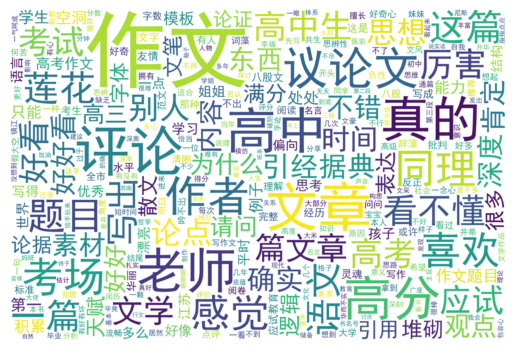

<Figure size 640x480 with 0 Axes>

In [33]:
# 根据词袋模型分析结果绘制词云图
from wordcloud import WordCloud
import matplotlib.pyplot as plt 

wordcloud = WordCloud(
    font_path='C:/Windows/Fonts/simhei.ttf',  # 指定中文字体文件路径
    background_color='white',  # 设置背景颜色
    width=1200,
    height=800,
    max_words=300,  # 设置最大显示的词数
    max_font_size=200  # 设置字体最大值
).generate_from_frequencies(word_freq)

# 显示词云图
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()
plt.savefig('评论分词2.png', dpi=100)
wordcloud.to_file('评论分词2.png')  